In [1]:
#Project setup

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Project root exists:", PROJECT_ROOT.exists())

Project root: C:\Users\Dell\Documents\Projects\AgriSense
Project root exists: True


In [2]:
# Imports

import numpy as np
import pandas as pd
import torch

from PIL import Image
from torchvision import transforms

from src.config import (
    CLEAN_METADATA_PATH,
    CLASSIFIER_CHECKPOINT,
    DEVICE,
    IMAGE_SIZE,
    load_disease_classes,
)

from src.models.classifier import load_classifier
from src.preprocessing.image_preprocessing import resize_and_pad

print("Imports successful")
print("Device:", DEVICE)

Imports successful
Device: cpu


In [3]:
#Load metadata and model

df = pd.read_csv(CLEAN_METADATA_PATH)

class_names = load_disease_classes()

model, checkpoint = load_classifier(
    CLASSIFIER_CHECKPOINT,
    num_classes=len(class_names),
    device=DEVICE,
)

model.eval()

print("Metadata records:", len(df))
print("Disease classes:", len(class_names))
print("Validation records:", (df["Split"] == "Validation").sum())
print("Model loaded successfully")

Metadata records: 7399
Disease classes: 115
Validation records: 811
Model loaded successfully


In [4]:
#Exact validation preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

print("Preprocessing ready")

Preprocessing ready


In [5]:
#Build absolute image lookup

IMAGE_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "PlantSeg"
    / "images"
).resolve()

print("Image directory:", IMAGE_DIR)
print("Exists:", IMAGE_DIR.exists())
print("Is directory:", IMAGE_DIR.is_dir())

if not IMAGE_DIR.is_dir():
    raise FileNotFoundError(
        f"PlantSeg image directory not found: {IMAGE_DIR}"
    )

image_lookup = {}

for image_path in IMAGE_DIR.rglob("*"):
    if image_path.is_file():
        image_lookup[image_path.name] = image_path

print("Images indexed:", len(image_lookup))

Image directory: C:\Users\Dell\Documents\Projects\AgriSense\data\raw\plantseg\images
Exists: True
Is directory: True
Images indexed: 7774


In [6]:
# Verify metadata-to-image matching

validation_df = df[df["Split"] == "Validation"].copy()

validation_df["image_path"] = validation_df["Name"].map(
    image_lookup
)

missing_images = validation_df["image_path"].isna().sum()

print("Validation records:", len(validation_df))
print("Matched images:", len(validation_df) - missing_images)
print("Missing images:", missing_images)

if missing_images > 0:
    print("\nFirst missing filenames:")
    print(
        validation_df.loc[
            validation_df["image_path"].isna(),
            "Name"
        ].head(10).tolist()
    )
else:
    print("\nAll validation images matched successfully.")

Validation records: 811
Matched images: 811
Missing images: 0

All validation images matched successfully.


In [7]:
# Run validation predictions

results = []

for _, row in validation_df.iterrows():

    image_path = row["image_path"]

    image = Image.open(image_path).convert("RGB")
    image = resize_and_pad(
        image,
        size=IMAGE_SIZE,
    )

    tensor = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(tensor)
        probabilities = torch.softmax(logits, dim=1)

    confidence, predicted_index = torch.max(
        probabilities,
        dim=1,
    )

    predicted_index = predicted_index.item()
    confidence = confidence.item()

    predicted_disease = class_names[predicted_index]
    actual_disease = row["Disease"]

    results.append({
        "image": row["Name"],
        "actual": actual_disease,
        "predicted": predicted_disease,
        "confidence": confidence,
        "correct": predicted_disease == actual_disease,
    })

confidence_df = pd.DataFrame(results)

print("Predictions completed:", len(confidence_df))
print("Columns:", confidence_df.columns.tolist())

Predictions completed: 811
Columns: ['image', 'actual', 'predicted', 'confidence', 'correct']


In [8]:
# Basic confidence statistics

print("Confidence statistics:")
print(
    confidence_df["confidence"].describe()
)

print("\nMean confidence:",
      confidence_df["confidence"].mean())

print("Validation accuracy:",
      confidence_df["correct"].mean())

Confidence statistics:
count    811.000000
mean       0.661258
std        0.290736
min        0.068284
25%        0.403868
50%        0.694681
75%        0.958305
max        0.999976
Name: confidence, dtype: float64

Mean confidence: 0.6612578095034518
Validation accuracy: 0.6214549938347719


In [9]:
# Correct vs incorrect confidence

confidence_summary = (
    confidence_df
    .groupby("correct")["confidence"]
    .agg(
        ["count", "mean", "median", "min", "max"]
    )
)

confidence_summary

,count,mean,median,min,max
correct,,,,,
False,307,0.483081,0.445045,0.068284,0.998244
True,504,0.769790,0.896742,0.088708,0.999976


In [10]:
# Confidence distribution

print("Correct predictions:")
print(
    confidence_df.loc[
        confidence_df["correct"],
        "confidence"
    ].describe()
)

print("\nIncorrect predictions:")
print(
    confidence_df.loc[
        ~confidence_df["correct"],
        "confidence"
    ].describe()
)

Correct predictions:
count    504.000000
mean       0.769790
std        0.256519
min        0.088708
25%        0.570276
50%        0.896742
75%        0.985486
max        0.999976
Name: confidence, dtype: float64

Incorrect predictions:
count    307.000000
mean       0.483081
std        0.253639
min        0.068284
25%        0.267487
50%        0.445045
75%        0.680856
max        0.998244
Name: confidence, dtype: float64


In [11]:
# Test candidate confidence thresholds

thresholds = np.arange(0.10, 0.96, 0.05)

threshold_results = []

for threshold in thresholds:

    accepted = confidence_df[
        confidence_df["confidence"] >= threshold
    ]

    rejected = confidence_df[
        confidence_df["confidence"] < threshold
    ]

    if len(accepted) > 0:
        accepted_accuracy = accepted["correct"].mean()
    else:
        accepted_accuracy = np.nan

    coverage = len(accepted) / len(confidence_df)

    threshold_results.append({
        "threshold": threshold,
        "accepted": len(accepted),
        "rejected": len(rejected),
        "coverage": coverage,
        "accepted_accuracy": accepted_accuracy,
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,threshold,accepted,rejected,coverage,accepted_accuracy
0,0.10,807,4,0.995068,0.622057
1,0.15,788,23,0.971640,0.633249
2,0.20,760,51,0.937115,0.647368
3,0.25,719,92,0.886560,0.666203
4,0.30,667,144,0.822441,0.692654
5,0.35,642,169,0.791615,0.699377
6,0.40,611,200,0.753391,0.711948
7,0.45,581,230,0.716400,0.738382
8,0.50,542,269,0.668311,0.758303
9,0.55,504,307,0.621455,0.769841


In [12]:
# Make the threshold results easier to read

threshold_display = threshold_df.copy()

threshold_display["coverage"] = (
    threshold_display["coverage"] * 100
).round(2)

threshold_display["accepted_accuracy"] = (
    threshold_display["accepted_accuracy"] * 100
).round(2)

threshold_display

,threshold,accepted,rejected,coverage,accepted_accuracy
0,0.10,807,4,99.51,62.21
1,0.15,788,23,97.16,63.32
2,0.20,760,51,93.71,64.74
3,0.25,719,92,88.66,66.62
4,0.30,667,144,82.24,69.27
5,0.35,642,169,79.16,69.94
6,0.40,611,200,75.34,71.19
7,0.45,581,230,71.64,73.84
8,0.50,542,269,66.83,75.83
9,0.55,504,307,62.15,76.98


In [13]:
# Save the analysis

OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "confidence_analysis_validation.csv"
)

threshold_df.to_csv(
    OUTPUT_PATH,
    index=False,
)

print("Saved:", OUTPUT_PATH)
print("File exists:", OUTPUT_PATH.exists())

Saved: C:\Users\Dell\Documents\Projects\AgriSense\data\processed\confidence_analysis_validation.csv
File exists: True


In [14]:
# Save detailed prediction results

PREDICTIONS_OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "validation_confidence_predictions.csv"
)

confidence_df.to_csv(
    PREDICTIONS_OUTPUT_PATH,
    index=False,
)

print("Saved:", PREDICTIONS_OUTPUT_PATH)
print("File exists:", PREDICTIONS_OUTPUT_PATH.exists())

Saved: C:\Users\Dell\Documents\Projects\AgriSense\data\processed\validation_confidence_predictions.csv
File exists: True


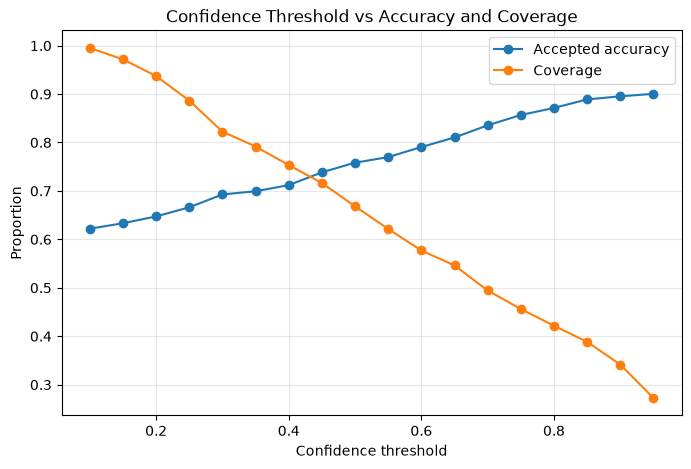

In [15]:
#Threshold analysis plot

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["accepted_accuracy"],
    marker="o",
    label="Accepted accuracy",
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["coverage"],
    marker="o",
    label="Coverage",
)

plt.xlabel("Confidence threshold")
plt.ylabel("Proportion")
plt.title("Confidence Threshold vs Accuracy and Coverage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
threshold_display.sort_values(
    "accepted_accuracy",
    ascending=False
).head(10)

,threshold,accepted,rejected,coverage,accepted_accuracy
17,0.95,221,590,27.25,90.05
16,0.90,277,534,34.16,89.53
15,0.85,315,496,38.84,88.89
14,0.80,342,469,42.17,87.13
13,0.75,370,441,45.62,85.68
12,0.70,401,410,49.45,83.54
11,0.65,443,368,54.62,81.04
10,0.60,468,343,57.71,79.06
9,0.55,504,307,62.15,76.98
8,0.50,542,269,66.83,75.83


In [17]:
#Prepare the test set

test_df = df[df["Split"] == "Test"].copy()

test_df["image_path"] = test_df["Name"].map(image_lookup)

missing_test_images = test_df["image_path"].isna().sum()

print("Test records:", len(test_df))
print("Matched images:", len(test_df) - missing_test_images)
print("Missing images:", missing_test_images)

if missing_test_images > 0:
    print("\nFirst missing filenames:")
    print(
        test_df.loc[
            test_df["image_path"].isna(),
            "Name"
        ].head(10).tolist()
    )

Test records: 1504
Matched images: 1504
Missing images: 0


In [18]:
# Test predictions

test_results = []

for _, row in test_df.iterrows():

    image_path = row["image_path"]

    image = Image.open(image_path).convert("RGB")
    image = resize_and_pad(
        image,
        size=IMAGE_SIZE,
    )

    tensor = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(tensor)
        probabilities = torch.softmax(logits, dim=1)

    confidence, predicted_index = torch.max(
        probabilities,
        dim=1,
    )

    predicted_index = predicted_index.item()
    confidence = confidence.item()

    predicted_disease = class_names[predicted_index]
    actual_disease = row["Disease"]

    test_results.append({
        "image": row["Name"],
        "actual": actual_disease,
        "predicted": predicted_disease,
        "confidence": confidence,
        "correct": predicted_disease == actual_disease,
    })

test_confidence_df = pd.DataFrame(test_results)

print("Test predictions completed:",
      len(test_confidence_df))

print(
    "Overall test accuracy:",
    test_confidence_df["correct"].mean()
)

Test predictions completed: 1504
Overall test accuracy: 0.6269946808510638


In [19]:
# Evaluate the selected threshold

SELECTED_THRESHOLD = 0.65

accepted_test = test_confidence_df[
    test_confidence_df["confidence"] >= SELECTED_THRESHOLD
]

rejected_test = test_confidence_df[
    test_confidence_df["confidence"] < SELECTED_THRESHOLD
]

accepted_accuracy = accepted_test["correct"].mean()
coverage = len(accepted_test) / len(test_confidence_df)

print("Selected threshold:", SELECTED_THRESHOLD)
print("Accepted predictions:", len(accepted_test))
print("Rejected predictions:", len(rejected_test))
print("Coverage:", round(coverage * 100, 2), "%")
print(
    "Accepted accuracy:",
    round(accepted_accuracy * 100, 2),
    "%"
)

Selected threshold: 0.65
Accepted predictions: 831
Rejected predictions: 673
Coverage: 55.25 %
Accepted accuracy: 82.67 %


In [20]:
from sklearn.metrics import accuracy_score, f1_score

test_accuracy = accuracy_score(
    test_confidence_df["actual"],
    test_confidence_df["predicted"],
)

test_macro_f1 = f1_score(
    test_confidence_df["actual"],
    test_confidence_df["predicted"],
    average="macro",
    zero_division=0,
)

test_weighted_f1 = f1_score(
    test_confidence_df["actual"],
    test_confidence_df["predicted"],
    average="weighted",
    zero_division=0,
)

print("Overall test accuracy:", round(test_accuracy * 100, 2), "%")
print("Test Macro F1:", round(test_macro_f1 * 100, 2), "%")
print("Test Weighted F1:", round(test_weighted_f1 * 100, 2), "%")

Overall test accuracy: 62.7 %
Test Macro F1: 51.48 %
Test Weighted F1: 61.24 %


In [21]:
# Comparing prediction differences

comparison = test_confidence_df.copy()

print("Test records:", len(comparison))
print("Correct predictions:", comparison["correct"].sum())
print("Incorrect predictions:", (~comparison["correct"]).sum())

print("\nPrediction distribution:")
print(comparison["predicted"].value_counts().head(10))

print("\nActual distribution:")
print(comparison["actual"].value_counts().head(10))

Test records: 1504
Correct predictions: 943
Incorrect predictions: 561

Prediction distribution:
predicted
citrus canker              78
grape downy mildew         59
wheat stripe rust          59
wheat head scab            41
apple scab                 38
wheat powdery mildew       37
tomato late blight         33
soybean mosaic             32
zucchini powdery mildew    32
corn smut                  31
Name: count, dtype: int64

Actual distribution:
actual
citrus canker                 65
wheat head scab               43
grape downy mildew            42
wheat stripe rust             42
apple scab                    35
wheat powdery mildew          35
squash powdery mildew         34
tomato early blight           31
cucumber angular leaf spot    30
zucchini powdery mildew       27
Name: count, dtype: int64


In [22]:
print("Model checkpoint:")
print(CLASSIFIER_CHECKPOINT)

print("\nNumber of classes:", len(class_names))
print("Test records:", len(test_confidence_df))
print("Image size:", IMAGE_SIZE)

Model checkpoint:
C:\Users\Dell\Documents\Projects\AgriSense\models\checkpoints\resnet18_extended_finetuned_latest.pth

Number of classes: 115
Test records: 1504
Image size: 224


In [23]:
from pathlib import Path

processed_dir = PROJECT_ROOT / "data" / "processed"

for path in processed_dir.glob("*.csv"):
    print(path.name)

agrisense_metadata_clean.csv
confidence_analysis_validation.csv
data_cleaning_audit.csv
validation_confidence_predictions.csv
